# 02 - Extraction Experiments

Test LLM extraction capabilities across different models and document types.

**Models:**
- Claude 3.5 Sonnet (API)
- Llama 3.2 Vision (local via Ollama)
- Tesseract (baseline)

**Metrics:**
- Field accuracy
- JSON validity
- Hallucination rate
- Latency

In [1]:
import sys
sys.path.insert(0, '..')

import json
from pathlib import Path
from tqdm.notebook import tqdm
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from src.data_loader import DataLoader
from src.extractors import ClaudeExtractor, OllamaExtractor, TesseractBaseline
from src.evaluators import ExtractionEvaluator, aggregate_results
from src.utils import ExperimentLogger, save_results

In [2]:
# Initialize
loader = DataLoader("../data")
evaluator = ExtractionEvaluator(fuzzy_threshold=80.0)
logger = ExperimentLogger(log_dir="../results")

print(f"Experiment ID: {logger.experiment_id}")

2026-06-29T00:10:19.200890 Experiment started: 20260629_001019

Experiment ID: 20260629_001019


## Initialize Extractors

In [3]:
# Initialize extractors
extractors = {}

# Claude (API)
try:
    claude = ClaudeExtractor(model="claude-sonnet-4-20250514")
    extractors["claude"] = claude
    print("✓ Claude extractor ready")
except Exception as e:
    print(f"✗ Claude not available: {e}")

# Ollama (local) - requires Ollama running with vision model
try:
    ollama = OllamaExtractor(model="llama3.2-vision")
    extractors["llama"] = ollama
    print("✓ Ollama extractor ready")
except Exception as e:
    print(f"✗ Ollama not available: {e}")

# Tesseract (baseline)
try:
    tesseract = TesseractBaseline()
    extractors["tesseract"] = tesseract
    print("✓ Tesseract baseline ready")
except Exception as e:
    print(f"✗ Tesseract not available: {e}")

print(f"\nActive extractors: {list(extractors.keys())}")

✓ Claude extractor ready
✓ Ollama extractor ready
✓ Tesseract baseline ready

Active extractors: ['claude', 'llama', 'tesseract']


## Load Test Documents

In [4]:
# Load documents
test_docs = []

# Try FUNSD first
try:
    funsd = list(loader.load_funsd(split="test"))[:20]  # Limit for quick testing
    test_docs.extend(funsd)
    print(f"Loaded {len(funsd)} FUNSD documents")
except FileNotFoundError:
    print("FUNSD not available")

# Try SROIE
try:
    sroie = list(loader.load_sroie(split="test"))[:20]
    test_docs.extend(sroie)
    print(f"Loaded {len(sroie)} SROIE documents")
except FileNotFoundError:
    print("SROIE not available")

# Fall back to samples
if not test_docs:
    samples = list(loader.load_samples())
    test_docs.extend(samples)
    print(f"Using {len(samples)} sample documents")

print(f"\nTotal test documents: {len(test_docs)}")

Loaded 20 FUNSD documents
SROIE not available

Total test documents: 20


## Run Extraction Experiment

In [5]:
# Run extractions
all_results = []

for extractor_name, extractor in extractors.items():
    print(f"\n{'='*50}")
    print(f"Running: {extractor_name}")
    print(f"{'='*50}")
    
    for doc in tqdm(test_docs, desc=extractor_name):
        # Extract
        result = extractor.extract(doc)
        
        # Evaluate if ground truth available
        if doc.ground_truth:
            eval_result = evaluator.evaluate(
                result.parsed_data,
                doc.ground_truth,
                doc.id,
                extractor_name
            )
        else:
            eval_result = None
        
        # Store
        all_results.append({
            "document_id": doc.id,
            "dataset": doc.dataset,
            "model": extractor_name,
            "extraction": result.to_dict(),
            "evaluation": eval_result.to_dict() if eval_result else None,
        })
        
        logger.add_result(all_results[-1])

print(f"\n\nCompleted {len(all_results)} extractions")


Running: claude


claude:   0%|          | 0/20 [00:00<?, ?it/s]


Running: llama


llama:   0%|          | 0/20 [00:00<?, ?it/s]


Running: tesseract


tesseract:   0%|          | 0/20 [00:00<?, ?it/s]



Completed 60 extractions


## Analyze Results

In [6]:
# Convert to DataFrame
rows = []
for r in all_results:
    if r["evaluation"]:
        rows.append({
            "document_id": r["document_id"],
            "dataset": r["dataset"],
            "model": r["model"],
            "field_accuracy": r["evaluation"]["field_accuracy"],
            "fuzzy_score": r["evaluation"]["fuzzy_score"],
            "cer": r["evaluation"]["cer"],
            "wer": r["evaluation"]["wer"],
            "json_valid": r["evaluation"]["json_valid"],
            "hallucinations": r["evaluation"]["hallucinations"],
            "latency_ms": r["extraction"]["latency_ms"],
        })

df = pd.DataFrame(rows)
df.head()

,document_id,dataset,model,field_accuracy,fuzzy_score,cer,wer,json_valid,hallucinations,latency_ms
0,82092117,funsd,claude,0.044444,4.444444,0.534662,0.654450,True,8,14657.899380
1,82200067_0069,funsd,claude,0.033058,3.305785,0.772962,0.923077,True,11,16563.699484
2,82250337_0338,funsd,claude,0.203125,20.312500,0.141270,0.296569,True,15,17484.422922
3,82251504,funsd,claude,0.138462,13.846154,0.452429,0.613583,True,17,17674.907446
4,82252956_2958,funsd,claude,0.161290,16.129032,0.548740,0.683544,True,3,11690.773726


In [7]:
# Summary by model
if not df.empty:
    summary = df.groupby("model").agg({
        "field_accuracy": "mean",
        "fuzzy_score": "mean",
        "cer": "mean",
        "json_valid": "mean",
        "hallucinations": "sum",
        "latency_ms": "mean",
    }).round(3)
    
    summary.columns = ["Avg Field Accuracy", "Avg Fuzzy Score", "Avg CER", 
                       "JSON Valid Rate", "Total Hallucinations", "Avg Latency (ms)"]
    display(summary)

,Avg Field Accuracy,Avg Fuzzy Score,Avg CER,JSON Valid Rate,Total Hallucinations,Avg Latency (ms)
model,,,,,,
claude,0.111,11.117,0.499,1.0,238,14186.325
llama,0.000,0.000,1.000,0.0,0,0.000
tesseract,0.000,0.000,1.000,0.0,0,0.000


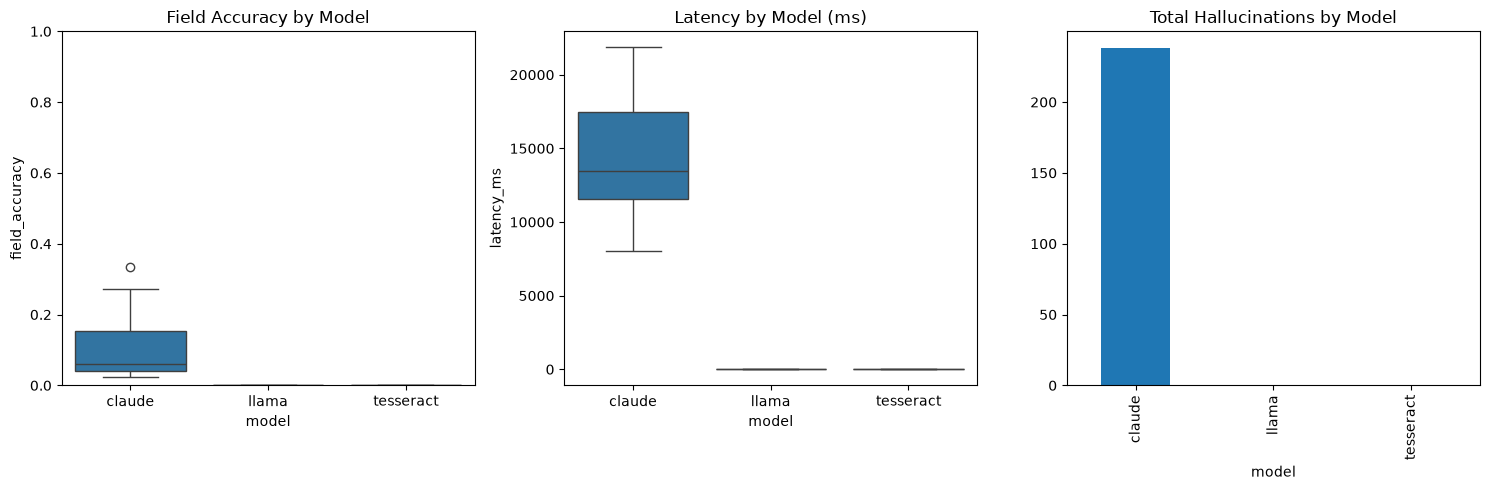

In [8]:
# Visualize: Accuracy by Model
if not df.empty:
    fig, axes = plt.subplots(1, 3, figsize=(15, 5))
    
    # Field Accuracy
    sns.boxplot(data=df, x="model", y="field_accuracy", ax=axes[0])
    axes[0].set_title("Field Accuracy by Model")
    axes[0].set_ylim(0, 1)
    
    # Latency
    sns.boxplot(data=df, x="model", y="latency_ms", ax=axes[1])
    axes[1].set_title("Latency by Model (ms)")
    
    # Hallucinations
    halluc_by_model = df.groupby("model")["hallucinations"].sum()
    halluc_by_model.plot(kind="bar", ax=axes[2])
    axes[2].set_title("Total Hallucinations by Model")
    
    plt.tight_layout()
    plt.savefig("../results/model_comparison.png", dpi=150)
    plt.show()

In [9]:
# Accuracy by dataset
if not df.empty and df["dataset"].nunique() > 1:
    fig, ax = plt.subplots(figsize=(10, 6))
    
    pivot = df.pivot_table(
        values="field_accuracy",
        index="model",
        columns="dataset",
        aggfunc="mean"
    )
    
    pivot.plot(kind="bar", ax=ax)
    ax.set_title("Field Accuracy by Model and Dataset")
    ax.set_ylabel("Accuracy")
    ax.set_ylim(0, 1)
    ax.legend(title="Dataset")
    
    plt.tight_layout()
    plt.savefig("../results/dataset_comparison.png", dpi=150)
    plt.show()

## Save Results

In [10]:
# Save all results
logger.save()

# Save summary
if not df.empty:
    df.to_csv(f"../results/{logger.experiment_id}/summary.csv", index=False)
    print(f"Results saved to: results/{logger.experiment_id}/")

2026-06-29T00:15:06.598203 Saved 60 results

Results saved to: results/20260629_001019/


## Example Extractions

Show some specific extraction examples for the article.

In [11]:
# Show example extraction
if all_results:
    example = all_results[0]
    
    print("=" * 50)
    print(f"Document: {example['document_id']}")
    print(f"Model: {example['model']}")
    print("=" * 50)
    
    print("\n--- Extracted Data ---")
    if example['extraction']['parsed_data']:
        print(json.dumps(example['extraction']['parsed_data'], indent=2)[:1000])
    else:
        print("No structured data extracted")
    
    if example['evaluation']:
        print("\n--- Evaluation ---")
        print(f"Field Accuracy: {example['evaluation']['field_accuracy']:.2%}")
        print(f"Hallucinations: {example['evaluation']['hallucinations']}")

Document: 82092117
Model: claude

--- Extracted Data ---
{
  "header": [
    "ATT. GEN. ADMIN.OFFICE Fax:614-466-5087     Dec 10 '98  17:46    P.01",
    "Attorney General",
    "Betty D. Montgomery",
    "CONFIDENTIAL FACSIMILE TRANSMISSION COVER SHEET",
    "FAX NO. (614) 466-5087"
  ],
  "questions": [
    "TO:",
    "FAX NUMBER:",
    "PHONE NUMBER:",
    "DATE:",
    "NUMBER OF PAGES INCLUDING COVER SHEET:",
    "SENDER/PHONE NUMBER:",
    "SPECIAL INSTRUCTIONS:",
    "NOTE:"
  ],
  "answers": [
    "George Baroody",
    "(336) 335-7392",
    "(336) 335-7363",
    "12/10/98",
    "3",
    "June Flynn for Eric Brown/(614) 466-8980"
  ],
  "other": [
    "IF YOU DO NOT RECEIVE ANY OF THE PAGES PROPERLY, PLEASE CONTACT SENDER AS SOON AS POSSIBLE",
    "THIS MESSAGE IS INTENDED ONLY FOR THE USE OF THE INDIVIDUAL OR ENTITY TO WHOM IT IS ADDRESSED AND MAY CONTAIN INFORMATION THAT IS PRIVILEGED, CONFIDENTIAL, AND EXEMPT FROM DISCLOSURE UNDER APPLICABLE LAW. If the reader of this message 

## Next Steps

1. Test chaos tolerance: `03_chaos_gradient_test.ipynb`
2. Deep analysis: `04_results_analysis.ipynb`